In [19]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
# Input
def client_input():
    '''
    purpose: function that gathers input when needed
    parameters: None
    return: tickers (str) - used to scrape information. 
            period (str) - used to gather time period of information.
    '''

    # Initialize empty list to hold ticker symbols
    tickers = []
    
    # While loop to gather ticker symbols from user input
    while True:
        ticker = input("Enter ticker symbol: ").upper()

        # Breaks loop if user entry is empty
        if ticker == "":
            break
        
        # Adds ticker to the end of the 'tickers' list
        tickers.append(ticker)

    # Gathers period of time for which to gather information
    period = input("Enter period (e.g. 2y, 1y, 6mo, 3mo, 1mo): ")

    return tickers, period

In [21]:
# Pull data
def pull_data(tickers, period):
    '''
    purpose: get raw historical price data from one ticker from yfinance
    parameter: ticker_symbol (str) - e.g. "AAPL". period (str) - e.g. "2y".
    return: hist (DataFrame) - daily price data, indexed by date. 
    '''

    # Create an empty dictionary to store the called data for each ticker
    market_data = {}
    
    # Loop through each ticker in the list of tickers and pull historical data for each
    for ticker in tickers:

        # Scrape information of current element (ticker) in the list of tickers
        ticker_scrape = yf.Ticker(ticker)
        hist = ticker_scrape.history(period = period)
        hist = hist.dropna(subset = ['Close'])

        # Add the historical DataFrame to the market_data dictionary with the ticker symbol as the key
        market_data[ticker] = hist

    return market_data

In [22]:
# Indicators
def calculate_indicators(market_data):
    '''
    purpose: add moving average (MA) columns to the price data.
    parameters: market_data (dict) - dictionary containing historical price data for each ticker.
    return: market_data (dict) 
    '''

    # Simple Moving Averages (SMA)
    def moving_avg(df):
        df['MA50'] = df['Close'].rolling(50).mean()
        df['MA200'] = df['Close'].rolling(200).mean()

        return df

    # Calculate Relative-Strength Index (RSI)
    def rsi(df):
        delta = df['Close'].diff()
        gain = delta.where(delta > 0, 0)
        loss = -delta.where(delta < 0, 0)

        avg_gain = gain.rolling(14).mean()
        avg_loss = loss.rolling(14).mean()

        rs = avg_gain / avg_loss
        df['RSI'] = 100 - (100 / (1+rs))

        return df
    
    # Loops through every (ticker -> df) pair in dictionary, giving ticker and value at one time
    for ticker, df in market_data.items():
        
        df = moving_avg(df)
        df = rsi(df)

        # Assigns mutated DataFrame back into dictionary using ticker (key)
        market_data[ticker] = df

    return market_data

In [23]:
# Signals 
def generate_signals(market_data):
    '''
    purpose: decide which days count as buy or sell, based on indicators.
    parameters: market_data (dict) - dictionary containing historical price data for each ticker.
    return: market_data (dict) - same data, with buy_signal and sell_signal columns added.
    '''

    # MA Signal
    def ma_signal(df):
        df['buy_signal'] = (df['MA50'] > df['MA200']) & (df['MA50'].shift(1) <= df['MA200'].shift(1))
        df['sell_signal'] = (df['MA50'] < df['MA200']) & (df['MA50'].shift(1) >= df['MA200'].shift(1))

        return df
    
    # RSI Signal
    def rsi_signal(df):
        oversold = df['RSI'] <= 30
        overbought = df['RSI'] >= 70

        return df
    
    for ticker, df in market_data.items():

        df = ma_signal(df)
        df = rsi_signal(df)

        market_data[ticker] = df

    return market_data

In [24]:
# Outer function
def run_backtest(market_data, initial_cash = 1000):
    '''
    purpose: walk through data day by day, simulating buys and sells.
    parameters: hist(DataFrame) - must contain buy_signal and sell_signal columns. 
                initial_cash(float) - starting cash.
    return: cash(float), shares(float), book_value(float) - ending state after the full simulation.
    '''
    # Inner function - runs buy/sell signal of given ticker
    def simulate(df, initial_cash):

        cash = initial_cash
        shares = 0
        book_value = 0
        shares_bought = 0

        for date, row in df.iterrows():
            price = row['Close']

            if row['buy_signal'] and cash >= price:
                spend = price
                shares_bought = spend / price
                shares += shares_bought
                cash -= spend
                book_value += spend
                print("\n", date, "BUY", round(shares, 2), "shares @", "$",round(price, 2))

            elif row['sell_signal'] and shares > 0:
                proceeds = shares * price
                realized_value = proceeds - book_value
                cash += proceeds
                shares = 0
                book_value = 0
                print("\n", date, "SELL", round(shares_bought, 2), "shares @", "$", round(price, 2), "Realized gain/loss:", round(realized_value, 2))

        return cash, shares, book_value

    # Create a dictonary that contains information on each ticker's holdings
    holdings = {}

    for ticker, df in market_data.items():
        cash, shares, book_value = simulate(df, initial_cash)
        holdings[ticker] = (cash, shares, book_value)

    return holdings

In [25]:
def plot_ticker(df, ticker):
    '''
    purpose: plot the closing price, MAs, and buy/sell signals for a given ticker.
    parameters: hist (DataFrame) - must contain Close, MA50, MA200, buy_signal, and sell_signal columns. 
                ticker_symbol (str) - used for chart title.
    return: None
    '''
    plt.figure(figsize = (12, 6))
    plt.plot(df.index, df['Close'], label = 'Close', alpha = 0.7)
    plt.plot(df.index, df['MA50'], label = 'MA50', color = "green")
    plt.plot(df.index, df['MA200'], label = 'MA200', color = "red")

    buys = df[df['buy_signal']]
    sells = df[df['sell_signal']]

    plt.scatter(buys.index, buys['Close'], 
                color = 'green', marker = '^', s = 100, label = 'Buy', zorder = 5)
    plt.scatter(sells.index, sells['Close'], 
                color = 'red', marker = 'v', s = 100, label = 'Sell', zorder = 5)
    
    plt.title(ticker)
    plt.legend()
    plt.show()

In [26]:
# Report
def summarize_results(market_data, holdings, initial_cash):
    '''
    purpose: turn ending cash/shares/book_value into readable results.
    parameters: hist(DataFrame), cash(float), shares(float), book_value(float), initial_cash(float)
    return: None - this function only prints
    '''
    for ticker, df in market_data.items():
        cash, shares, book_value = holdings[ticker]

        final_price = df['Close'].iloc[-1]
        current_value_of_holdings = shares * final_price
        portfolio_value = cash + current_value_of_holdings
        overall_return = (portfolio_value - initial_cash) / initial_cash

        print(f"\n--- Summary: {ticker} ---")
        print(f"Available cash: ${cash:,.2f}")
        print(f"Current value of holdings: ${current_value_of_holdings:,.2f}")

        if shares > 0:
            holding_return = (current_value_of_holdings - book_value) / book_value
            holding_gain_loss = current_value_of_holdings - book_value

            print(f"Book Value (cost basis) of holdings: ${book_value:,.2f}")
            print(f"Return on holdings: {holding_return:.2%}")
            print(f"Gain/loss on holdings: ${holding_gain_loss:,.2f}")

        print(f"Total portfolio value: ${portfolio_value:,.2f}")
        print(f"Overall return (start to end): {overall_return:.2%}")


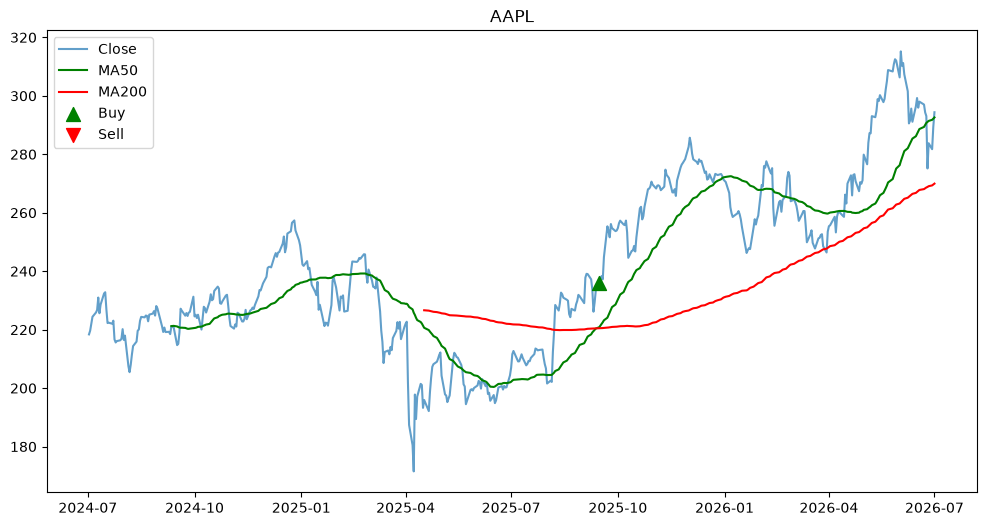

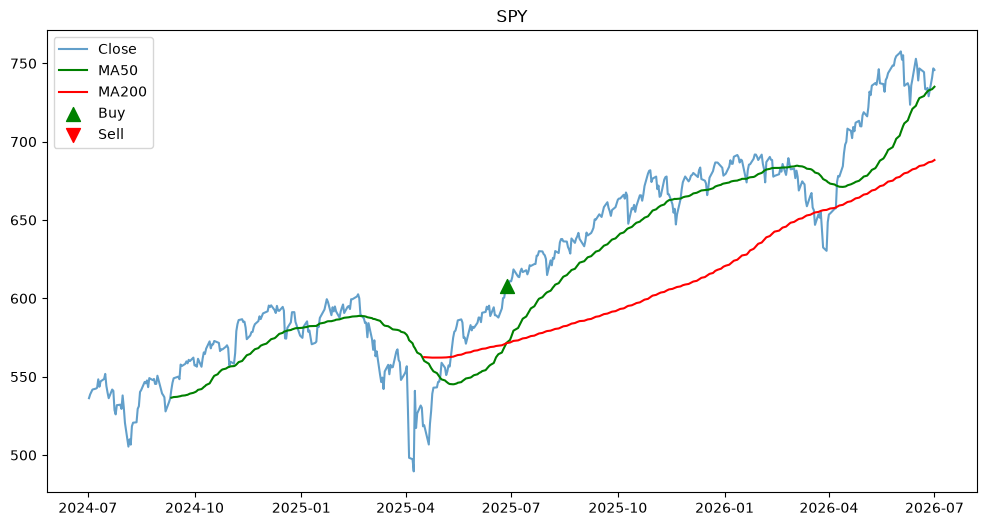


 2025-09-15 00:00:00-04:00 BUY 1.0 shares @ $ 236.03

 2025-06-27 00:00:00-04:00 BUY 1.0 shares @ $ 608.17

--- Summary: AAPL ---
Available cash: $763.97
Current value of holdings: $294.38
Book Value (cost basis) of holdings: $236.03
Return on holdings: 24.72%
Gain/loss on holdings: $58.35
Total portfolio value: $1,058.35
Overall return (start to end): 5.83%

--- Summary: SPY ---
Available cash: $391.83
Current value of holdings: $745.76
Book Value (cost basis) of holdings: $608.17
Return on holdings: 22.62%
Gain/loss on holdings: $137.59
Total portfolio value: $1,137.59
Overall return (start to end): 13.76%


In [27]:
# Main function
def run_engine():
    '''
    purpose: call the helper functions to run the backtest engine.
    parameters: None
    return: None - this function only prints
    '''
    tickers, period = client_input()
    market_data = pull_data(tickers, period)
    market_data = calculate_indicators(market_data)
    market_data = generate_signals(market_data)

    for ticker, df in market_data.items():
        plot_ticker(df, ticker)

    holdings = run_backtest(market_data, initial_cash = 1000)
    summarize_results(market_data, holdings, initial_cash = 1000)

# actually runs the main function
run_engine()